# ️Proyecto AUDIO - Análisis de Comunicaciones ATC
## Análisis de Datos No Estructurados 2025-2026

**Dataset:** ATCOSIM Corpus  
**Objetivo:** Clasificación y análisis de comunicaciones aeronáuticas

## ️ 0. CONFIGURACIÓN INICIAL

**IMPORTANTE:** Ejecuta esta celda primero si estás trabajando en Google Colab o un entorno nuevo.

In [44]:
from pathlib import Path
NOTEBOOK_OUTPUT_DIR = Path("outputs") / "ADNE_Proyecto_Audio_ATC_EDA"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {NOTEBOOK_OUTPUT_DIR.resolve()}")

Output directory: /Users/pablomoreno/Desktop/ANALISIS/Proyecto_ATC_Comunicaciones_Aeronauticas/outputs/ADNE_Proyecto_Audio_ATC_EDA


##  1. Instalación de Dependencias

In [45]:
%%capture

import sys
import shutil

print(" Instalando dependencias...")
print("Esto puede tardar 3-5 minutos en la primera ejecución.\n")

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy

!{sys.executable} -m pip install datasets

!{sys.executable} -m pip install librosa soundfile

!{sys.executable} -m pip install scikit-learn

!{sys.executable} -m pip uninstall -y torch torchvision torchaudio torchcodec
!{sys.executable} -m pip install "torch==2.10.*" "torchvision==0.25.*" "torchaudio==2.10.*" --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install "torchcodec==0.10.*"

!{sys.executable} -m pip install transformers

!{sys.executable} -m pip install matplotlib seaborn

!{sys.executable} -m pip install jiwer

!{sys.executable} -m pip install IPython

if shutil.which("ffmpeg") is None:
    print("️ FFmpeg no encontrado en PATH. Instálalo en tu sistema/entorno para usar torchcodec.")

In [46]:
print(" Verificando instalación...\n")

import sys
import shutil
print(f"Python ejecutable activo: {sys.executable}")

try:
    import pandas as pd
    print(f" pandas {pd.__version__}")
except ImportError:
    print(" pandas NO instalado")

try:
    import numpy as np
    print(f" numpy {np.__version__}")
except ImportError:
    print(" numpy NO instalado")

try:
    import librosa
    print(f" librosa {librosa.__version__}")
except ImportError:
    print(" librosa NO instalado")

torch_ok = False
try:
    import torch
    print(f" torch {torch.__version__}")
    torch_ok = torch.__version__.startswith("2.10")
    if not torch_ok:
        print("️ torch no está en 2.10.x. Reinicia kernel y re-ejecuta instalación.")
except ImportError:
    print(" torch NO instalado")

try:
    import torchcodec
    print(f" torchcodec {torchcodec.__version__}")
except ImportError:
    print(" torchcodec NO instalado")
except Exception as e:
    print(f" torchcodec con error de runtime: {e}")
    if not torch_ok:
        print(" Probable causa: el kernel sigue cargando torch viejo. Reinicia kernel y vuelve a probar.")

try:
    import transformers
    print(f" transformers {transformers.__version__}")
except ImportError:
    print(" transformers NO instalado")

try:
    from datasets import load_dataset
    print(f" datasets instalado")
except ImportError:
    print(" datasets NO instalado")

if shutil.which("ffmpeg") is not None:
    print(" ffmpeg disponible")
else:
    print(" ffmpeg NO encontrado (requerido por torchcodec)")

 Verificando instalación...

Python ejecutable activo: /opt/anaconda3/envs/atc_env/bin/python
 pandas 2.3.3
 numpy 1.26.4
 librosa 0.11.0
 torch 2.10.0
 torchcodec 0.10.0
 transformers 5.3.0
 datasets instalado
 ffmpeg disponible


##  2. Importar Librerías

Ahora que todo está instalado, importamos las librerías.

In [47]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import os

import librosa
import librosa.display
import soundfile as sf

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio

from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from transformers import WhisperProcessor, WhisperForConditionalGeneration

import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')  # Cambiado para mayor compatibilidad
sns.set_palette("husl")
%matplotlib inline

print("Librerías importadas correctamente")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Usando CPU (el entrenamiento será más lento)")

Librerías importadas correctamente
PyTorch version: 2.10.0
CUDA disponible: False
Usando CPU (el entrenamiento será más lento)


##  3. Carga del Dataset ATCOSIM

Cargamos el dataset ATCOSIM desde Hugging Face. Este dataset contiene:
- 10 horas de comunicaciones ATC simuladas
- 10 controladores no nativos
- Transcripciones manuales
- Audio de alta calidad (headset)

In [48]:
print(" Descargando dataset ATCOSIM...")
print("Esta operación puede tardar varios minutos la primera vez.\n")

ds = load_dataset("Jzuluaga/atcosim_corpus")

print("\n Dataset cargado exitosamente")
print(f"\nEstructura del dataset:")
print(ds)

 Descargando dataset ATCOSIM...
Esta operación puede tardar varios minutos la primera vez.


 Dataset cargado exitosamente

Estructura del dataset:
DatasetDict({
    train: Dataset({
        features: ['id', 'audio', 'text', 'segment_start_time', 'segment_end_time', 'duration'],
        num_rows: 7638
    })
    test: Dataset({
        features: ['id', 'audio', 'text', 'segment_start_time', 'segment_end_time', 'duration'],
        num_rows: 1901
    })
})


In [49]:
print("Splits disponibles:", list(ds.keys()))

print("\nEstructura del dataset:")
train_data = ds['train'] if 'train' in ds else ds[list(ds.keys())[0]]
print(f"Número de muestras en el primer split: {len(train_data)}")
print("\nCampos disponibles:")
print(train_data.features)
print("\n" + "="*80)
print("Primer ejemplo:")
print("="*80)
first_example = train_data[0]
for key, value in first_example.items():
    if key == 'audio':
        print(f"\n{key}:")
        print(f"  - sampling_rate: {value['sampling_rate']}")
        print(f"  - array shape: {value['array'].shape}")
        print(f"  - duration: {len(value['array']) / value['sampling_rate']:.2f} segundos")
    else:
        print(f"\n{key}: {value}")

Splits disponibles: ['train', 'test']

Estructura del dataset:
Número de muestras en el primer split: 7638

Campos disponibles:
{'id': Value('string'), 'audio': Audio(sampling_rate=16000, decode=True, num_channels=None, stream_index=None), 'text': Value('string'), 'segment_start_time': Value('float32'), 'segment_end_time': Value('float32'), 'duration': Value('float32')}

Primer ejemplo:

id: atcosim_sm1_01_001_000000_000329

audio:
  - sampling_rate: 16000
  - array shape: (52797,)
  - duration: 3.30 segundos

text: psa eight one zero turn right to trasadingen

segment_start_time: 0.0

segment_end_time: 3.299999952316284

duration: 3.299999952316284


##  4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

### 4.1 Estadísticas Básicas del Dataset

In [50]:
data_dict = {}
for key in train_data.features.keys():
    if key != 'audio':
        data_dict[key] = [train_data[i][key] for i in range(len(train_data))]

df_train = pd.DataFrame(data_dict)

print("Información del Dataset:")
print(f"\nTotal de muestras: {len(df_train)}")
print(f"\nColumnas disponibles: {df_train.columns.tolist()}")
print(f"\nPrimeras 5 filas:")
display(df_train.head())

Información del Dataset:

Total de muestras: 7638

Columnas disponibles: ['id', 'text', 'segment_start_time', 'segment_end_time', 'duration']

Primeras 5 filas:


,id,text,segment_start_time,segment_end_time,duration
0,atcosim_sm1_01_001_000000_000329,psa eight one zero turn right to trasadingen,0.0,3.30,3.30
1,atcosim_sm1_01_002_000000_000466,lufthansa five three one eight contact zurich ...,0.0,4.66,4.66
2,atcosim_sm1_01_003_000000_000422,psa eight one zero contact zurich one three th...,0.0,4.23,4.23
3,atcosim_sm1_01_004_000000_000264,sabena four eight one rhein identified,0.0,2.64,2.64
4,atcosim_sm1_01_005_000000_000391,transwede one zero one rhein identified set co...,0.0,3.91,3.91


In [51]:
print("ℹ️ Información del DataFrame:")
df_train.info()

print("\nValores nulos por columna:")
print(df_train.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df_train.describe(include='all'))

ℹ️ Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7638 entries, 0 to 7637
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  7638 non-null   object 
 1   text                7638 non-null   object 
 2   segment_start_time  7638 non-null   float64
 3   segment_end_time    7638 non-null   float64
 4   duration            7638 non-null   float64
dtypes: float64(3), object(2)
memory usage: 298.5+ KB

Valores nulos por columna:
id                    0
text                  0
segment_start_time    0
segment_end_time      0
duration              0
dtype: int64

Estadísticas descriptivas:


,id,text,segment_start_time,segment_end_time,duration
count,7638,7638,7638.0,7638.000000,7638.000000
unique,7638,5975,NaN,NaN,NaN
top,atcosim_sm1_01_001_000000_000329,roger,NaN,NaN,NaN
freq,1,38,NaN,NaN,NaN
mean,NaN,NaN,0.0,3.956612,3.956612
std,NaN,NaN,0.0,1.519211,1.519211
min,NaN,NaN,0.0,0.140000,0.140000
25%,NaN,NaN,0.0,3.090000,3.090000
50%,NaN,NaN,0.0,3.800000,3.800000
75%,NaN,NaN,0.0,4.650000,4.650000


### 4.2 Análisis de Transcripciones

Columnas de texto encontradas: ['text']

 Estadísticas de transcripciones:
       text_length   word_count
count  7638.000000  7638.000000
mean     62.794056    11.095575
std      23.243289     4.111262
min       2.000000     1.000000
25%      48.000000     8.000000
50%      63.000000    11.000000
75%      75.000000    13.000000
max     302.000000    71.000000


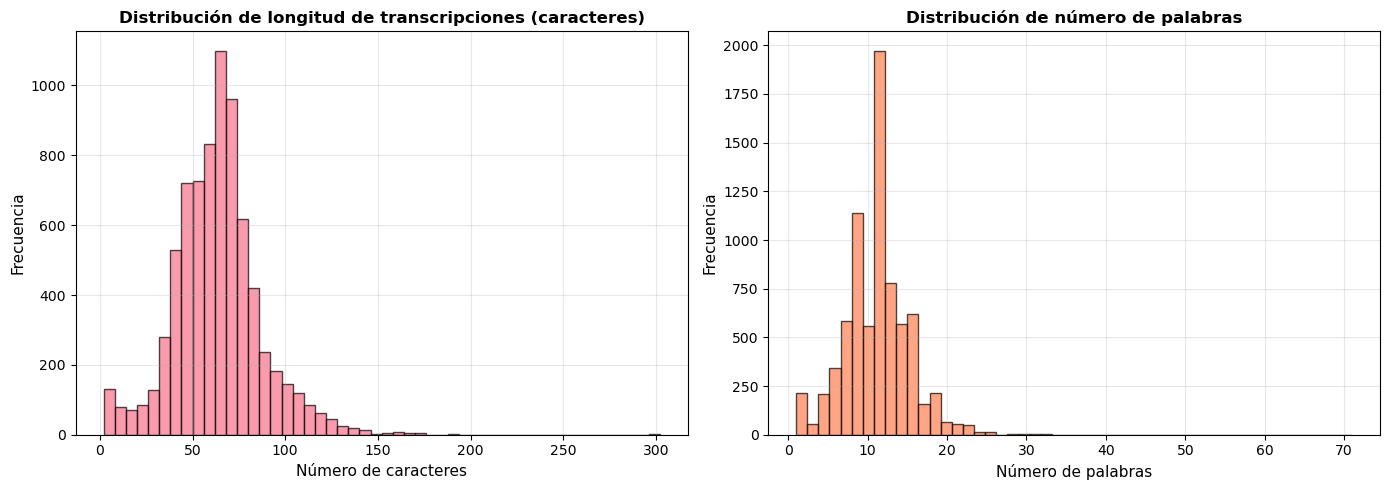


 Ejemplos de transcripciones:

1. psa eight one zero turn right to trasadingen

2. lufthansa five three one eight contact zurich one three four decimal six

3. psa eight one zero contact zurich one three three decimal four

4. sabena four eight one rhein identified

5. transwede one zero one rhein identified set course trasadingen


In [52]:
text_columns = [col for col in df_train.columns if 'text' in col.lower() or 'transcript' in col.lower()]
print(f"Columnas de texto encontradas: {text_columns}")

if text_columns:
    text_col = text_columns[0]
    
    df_train['text_length'] = df_train[text_col].astype(str).str.len()
    df_train['word_count'] = df_train[text_col].astype(str).str.split().str.len()
    
    print(f"\n Estadísticas de transcripciones:")
    print(df_train[['text_length', 'word_count']].describe())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(df_train['text_length'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Número de caracteres', fontsize=11)
    axes[0].set_ylabel('Frecuencia', fontsize=11)
    axes[0].set_title('Distribución de longitud de transcripciones (caracteres)', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(df_train['word_count'], bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_xlabel('Número de palabras', fontsize=11)
    axes[1].set_ylabel('Frecuencia', fontsize=11)
    axes[1].set_title('Distribución de número de palabras', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n Ejemplos de transcripciones:")
    for i in range(min(5, len(df_train))):
        print(f"\n{i+1}. {df_train[text_col].iloc[i]}")
else:
    print("\n️ No se encontraron columnas de texto/transcripción")

### 4.3 Análisis de Audio

Analizaremos las características del audio: duración, sample rate, y visualizaremos formas de onda y espectrogramas.

In [53]:
def get_audio_info(audio_sample):
    """
    Extrae información básica del audio
    audio_sample: diccionario con 'array' y 'sampling_rate'
    """
    audio_array = audio_sample['array']
    sr = audio_sample['sampling_rate']
    duration = len(audio_array) / sr
    
    return {
        'duration': duration,
        'sample_rate': sr,
        'num_samples': len(audio_array),
        'max_amplitude': np.max(np.abs(audio_array)),
        'mean_amplitude': np.mean(np.abs(audio_array))
    }

N_SAMPLES = min(100, len(train_data))
print(f"Analizando {N_SAMPLES} muestras de audio...")
print("Esto puede tardar 1-2 minutos...\n")

audio_info_list = []
for i in range(N_SAMPLES):
    if i % 20 == 0:
        print(f"Procesando muestra {i+1}/{N_SAMPLES}...")
    info = get_audio_info(train_data[i]['audio'])
    audio_info_list.append(info)

df_audio_info = pd.DataFrame(audio_info_list)

print("\nEstadísticas de audio:")
display(df_audio_info.describe())

Analizando 100 muestras de audio...
Esto puede tardar 1-2 minutos...

Procesando muestra 1/100...
Procesando muestra 21/100...
Procesando muestra 41/100...
Procesando muestra 61/100...
Procesando muestra 81/100...

Estadísticas de audio:


,duration,sample_rate,num_samples,max_amplitude,mean_amplitude
count,100.000000,100.0,100.000000,100.000000,100.000000
mean,4.256147,16000.0,68098.350000,0.760561,0.023492
std,2.566926,0.0,41070.819745,0.172813,0.006955
min,1.425188,16000.0,22803.000000,0.386737,0.006481
25%,3.175828,16000.0,50813.250000,0.637880,0.018803
50%,3.920000,16000.0,62720.000000,0.748389,0.023144
75%,4.524016,16000.0,72384.250000,0.917670,0.028629
max,20.600000,16000.0,329600.000000,1.074244,0.043073


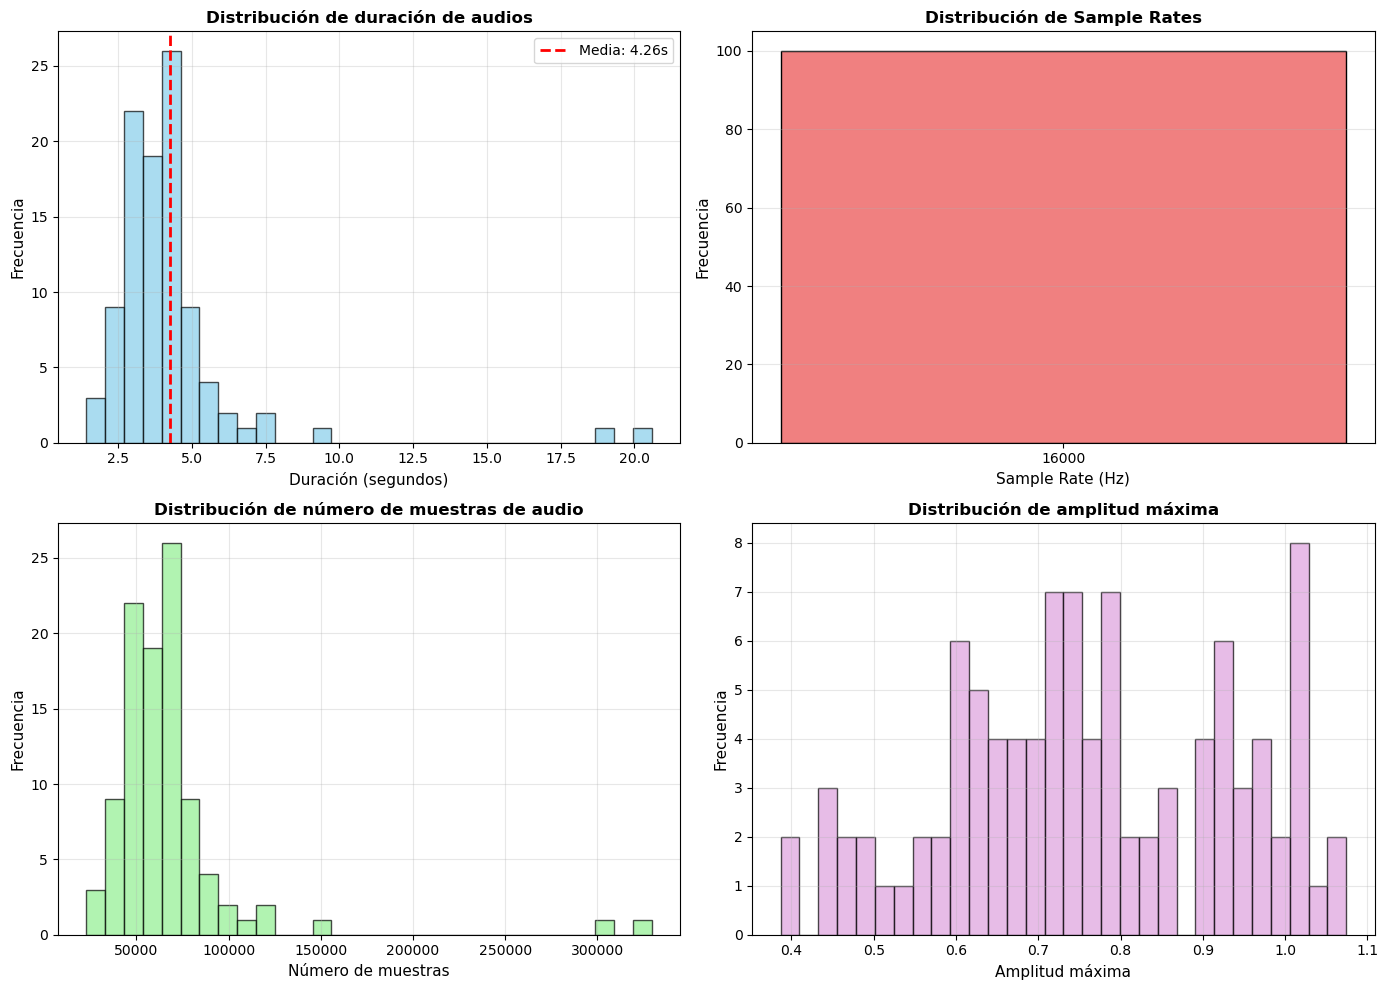


⏱️ Duración total analizada: 0.12 horas
 Duración total estimada del dataset completo: 9.03 horas


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_audio_info['duration'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Duración (segundos)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].set_title('Distribución de duración de audios', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df_audio_info['duration'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Media: {df_audio_info["duration"].mean():.2f}s')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

sample_rates = df_audio_info['sample_rate'].value_counts()
axes[0, 1].bar(range(len(sample_rates)), sample_rates.values, color='lightcoral', edgecolor='black')
axes[0, 1].set_xticks(range(len(sample_rates)))
axes[0, 1].set_xticklabels(sample_rates.index)
axes[0, 1].set_xlabel('Sample Rate (Hz)', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Sample Rates', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].hist(df_audio_info['num_samples'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Número de muestras', fontsize=11)
axes[1, 0].set_ylabel('Frecuencia', fontsize=11)
axes[1, 0].set_title('Distribución de número de muestras de audio', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(df_audio_info['max_amplitude'], bins=30, edgecolor='black', alpha=0.7, color='plum')
axes[1, 1].set_xlabel('Amplitud máxima', fontsize=11)
axes[1, 1].set_ylabel('Frecuencia', fontsize=11)
axes[1, 1].set_title('Distribución de amplitud máxima', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

total_duration_hours = df_audio_info['duration'].sum() / 3600
estimated_total_hours = (total_duration_hours / N_SAMPLES) * len(train_data)

print(f"\n⏱️ Duración total analizada: {total_duration_hours:.2f} horas")
print(f" Duración total estimada del dataset completo: {estimated_total_hours:.2f} horas")

### 4.4 Visualización de Formas de Onda y Espectrogramas

Vamos a visualizar algunos ejemplos de audio para entender mejor los datos.

In [55]:
def plot_audio_analysis(audio_dict, text="", idx=0):
    """
    Visualiza forma de onda, espectrograma y mel-espectrograma de un audio
    """
    audio_array = audio_dict['array']
    sr = audio_dict['sampling_rate']
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    librosa.display.waveshow(audio_array, sr=sr, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Forma de onda - Muestra {idx}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Tiempo (s)', fontsize=11)
    axes[0].set_ylabel('Amplitud', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    D = librosa.stft(audio_array)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='viridis')
    axes[1].set_title('Espectrograma (STFT)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Frecuencia (Hz)', fontsize=11)
    fig.colorbar(img1, ax=axes[1], format='%+2.0f dB')
    
    S = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=128)
    S_db_mel = librosa.power_to_db(S, ref=np.max)
    img2 = librosa.display.specshow(S_db_mel, sr=sr, x_axis='time', y_axis='mel', ax=axes[2], cmap='magma')
    axes[2].set_title('Mel-Espectrograma', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Tiempo (s)', fontsize=11)
    axes[2].set_ylabel('Frecuencia Mel', fontsize=11)
    fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')
    
    if text:
        fig.suptitle(f'Transcripción: "{text}"', fontsize=11, style='italic', y=0.995)
    
    plt.tight_layout()
    plt.show()

Visualización de ejemplos de audio:


Muestra 0
Transcripción: psa eight one zero turn right to trasadingen
Audio:


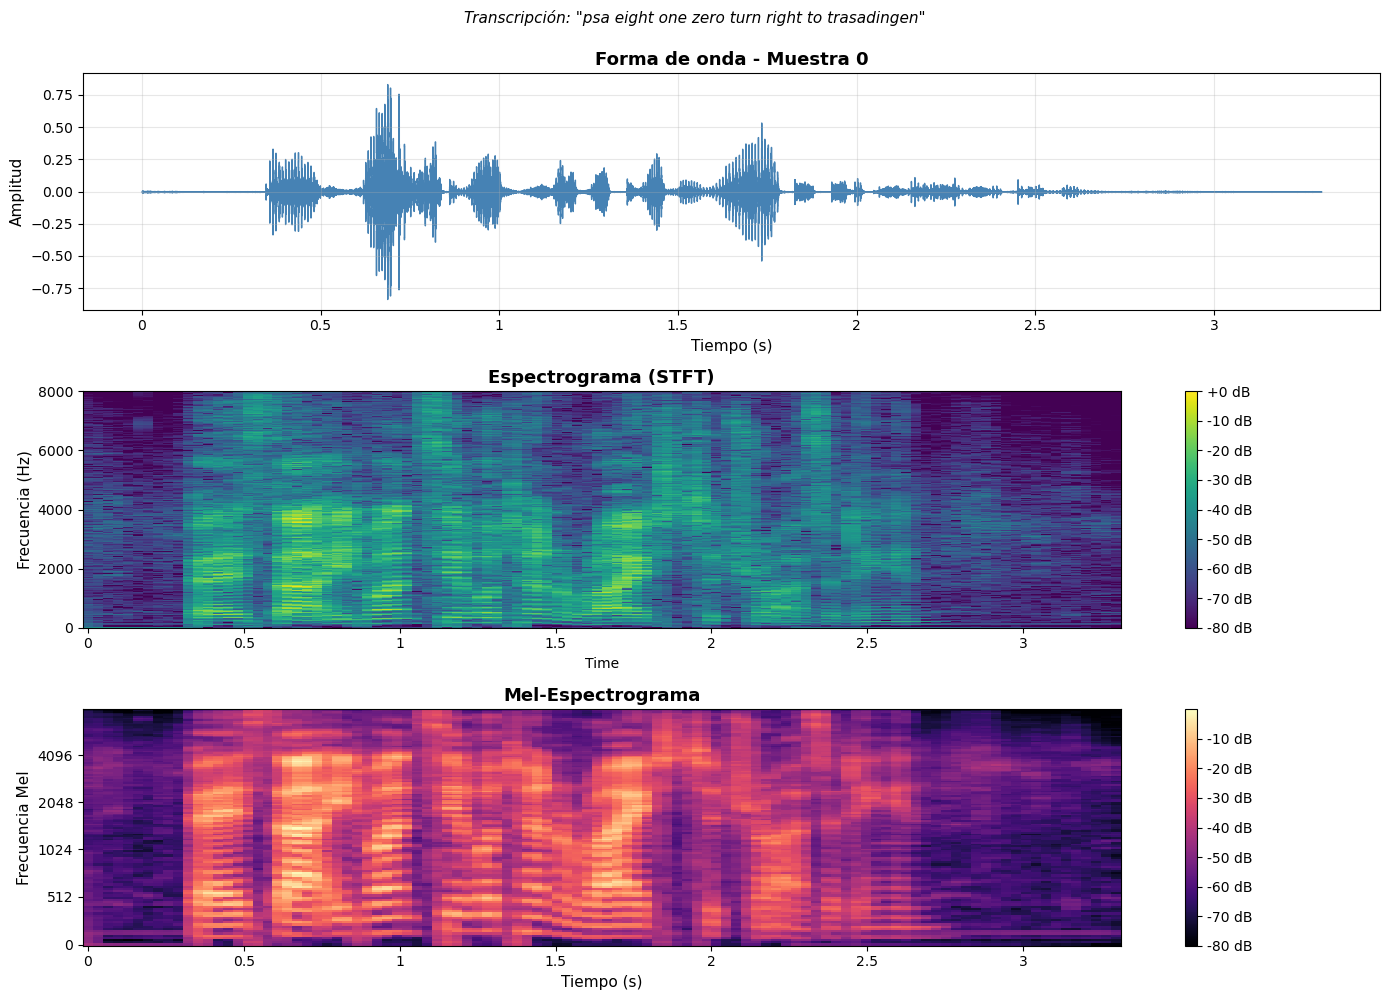


Muestra 10
Transcripción: swiss air nine three five two climb flight level three five zero set course to gotil
Audio:


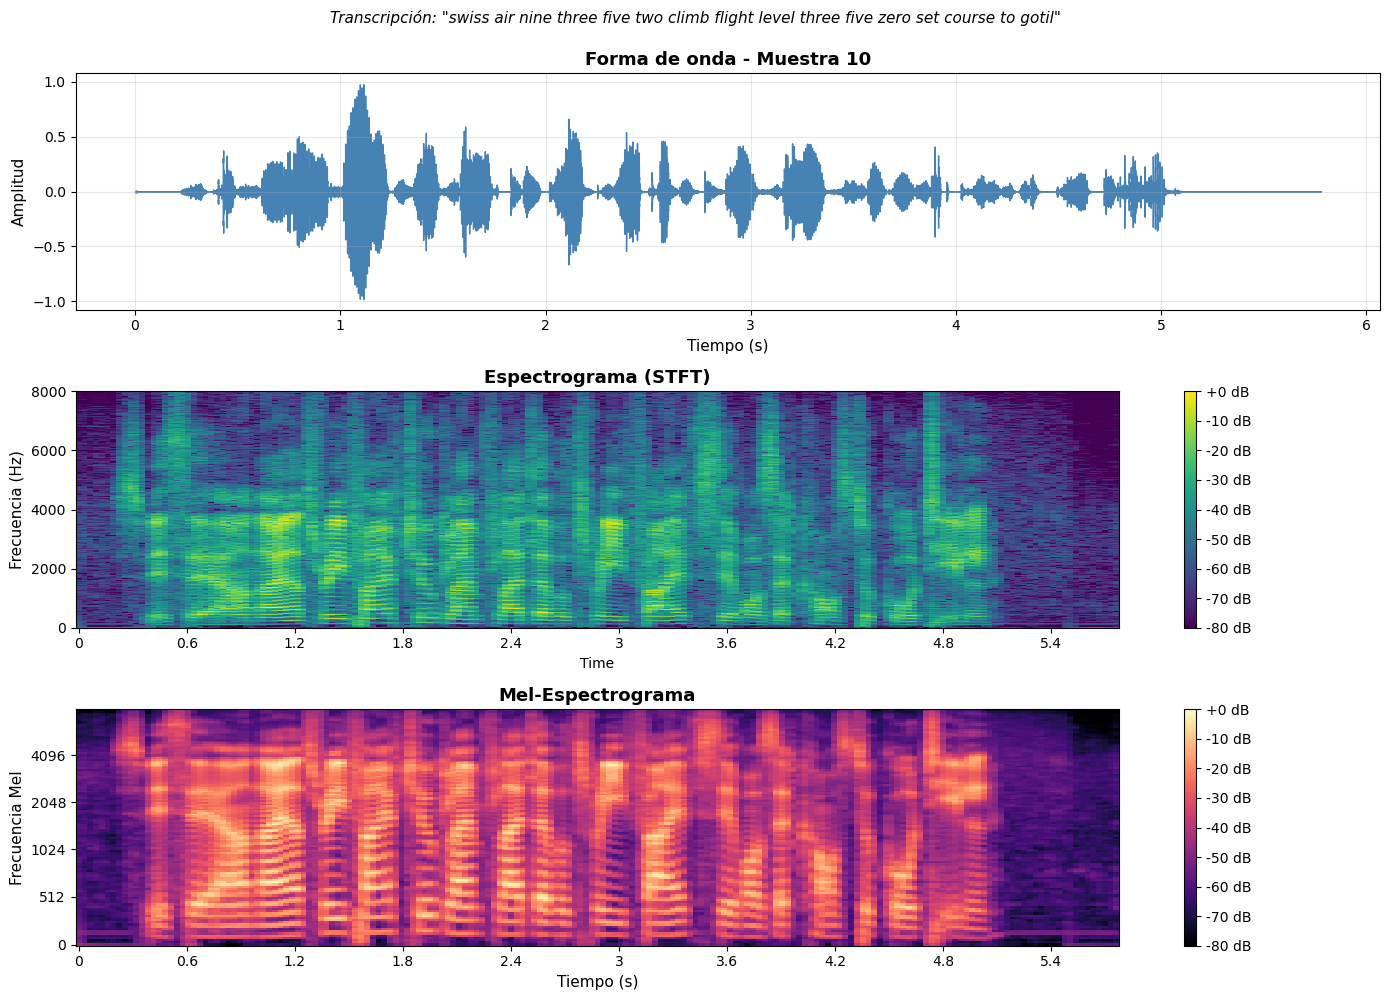


Muestra 25
Transcripción: hapag lloyd six five three climb flight level two nine zero set course trasadingen
Audio:


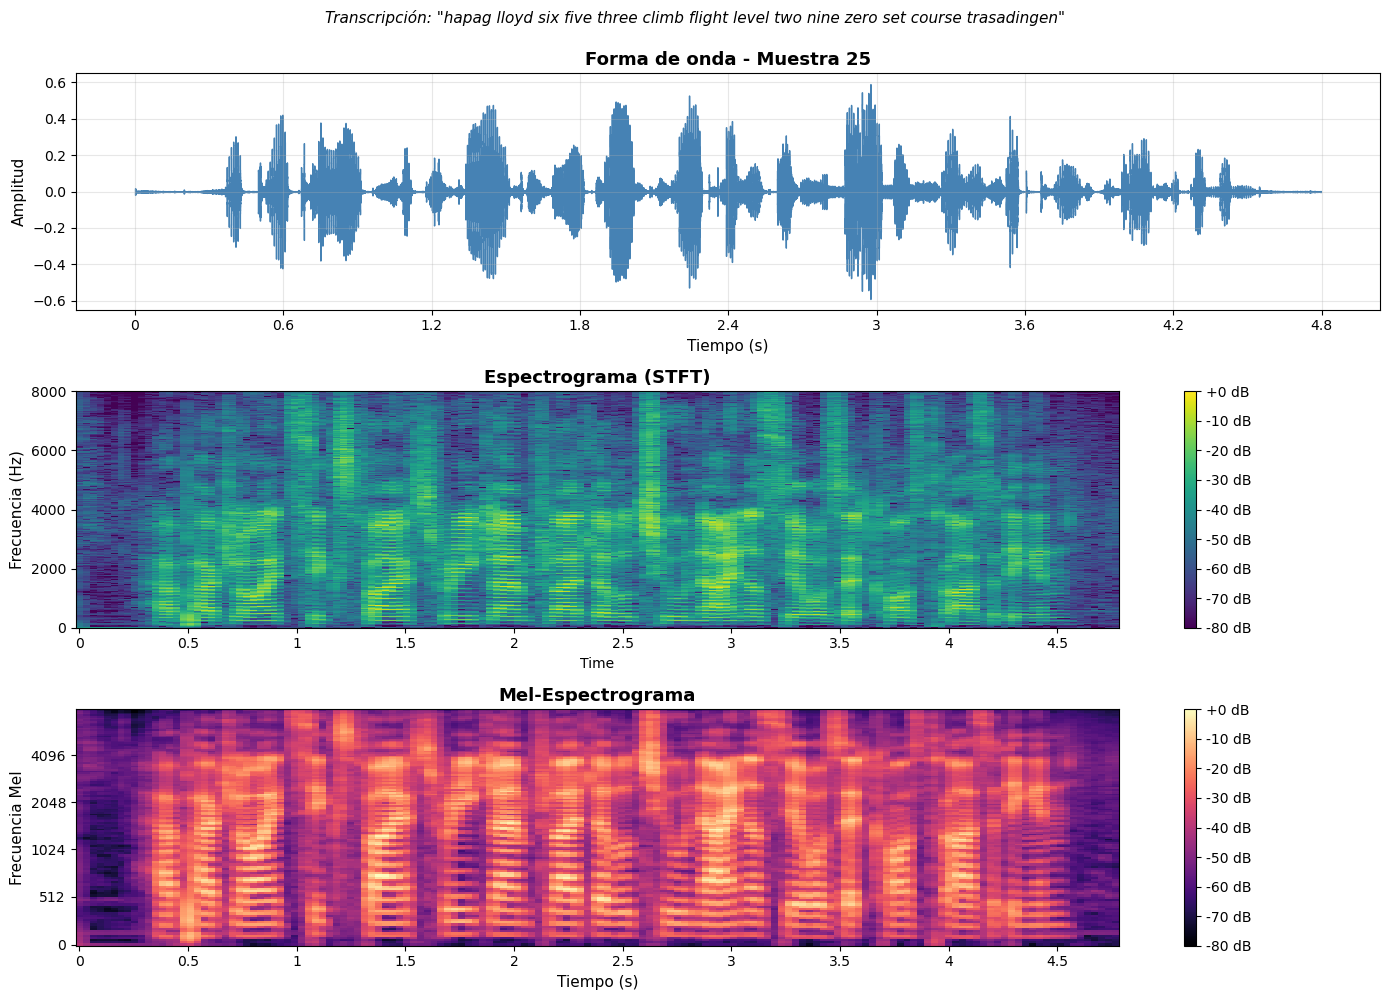

In [56]:
indices_to_plot = [0, min(10, len(train_data)-1), min(25, len(train_data)-1)]
print("Visualización de ejemplos de audio:\n")
for idx in indices_to_plot:
    sample = train_data[idx]
    
    text = ""
    for possible_key in ['text', 'transcript', 'transcription']:
        if possible_key in sample:
            text = str(sample[possible_key])
            break
    
    print(f"\n{'='*80}")
    print(f"Muestra {idx}")
    if text:
        print(f"Transcripción: {text}")
    print(f"{'='*80}")
    
    print("Audio:")
    display(Audio(sample['audio']['array'], rate=sample['audio']['sampling_rate']))
    
    plot_audio_analysis(sample['audio'], text, idx)

### 4.5 Extracción de Features de Audio

Extraemos características relevantes para el análisis:
- MFCCs (Mel-Frequency Cepstral Coefficients)
- Spectral features (centroid, rolloff, bandwidth)
- Zero crossing rate
- Chroma features

In [57]:
def extract_audio_features(audio_dict):
    """
    Extrae features completos de un audio
    """
    audio_array = audio_dict['array']
    sr = audio_dict['sampling_rate']
    
    features = {}
    
    mfccs = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=13)
    features['mfcc_mean'] = np.mean(mfccs, axis=1)
    features['mfcc_std'] = np.std(mfccs, axis=1)
    
    spectral_centroid = librosa.feature.spectral_centroid(y=audio_array, sr=sr)
    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    features['spectral_centroid_std'] = np.std(spectral_centroid)
    
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_array, sr=sr)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
    features['spectral_rolloff_std'] = np.std(spectral_rolloff)
    
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio_array, sr=sr)
    features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
    features['spectral_bandwidth_std'] = np.std(spectral_bandwidth)
    
    zcr = librosa.feature.zero_crossing_rate(audio_array)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    chroma = librosa.feature.chroma_stft(y=audio_array, sr=sr)
    features['chroma_mean'] = np.mean(chroma, axis=1)
    features['chroma_std'] = np.std(chroma, axis=1)
    
    rms = librosa.feature.rms(y=audio_array)
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    return features

print("Extrayendo features de ejemplo...")

sample_features = extract_audio_features(train_data[0]['audio'])

print("\nFeatures extraídos por audio:")
feature_count = 0
for key, value in sample_features.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: array de tamaño {value.shape}")
        feature_count += len(value)
    else:
        print(f"  {key}: {value:.4f}")
        feature_count += 1

print(f"\nTotal de features por audio: {feature_count}")
print("Extracción de features implementada correctamente")

Extrayendo features de ejemplo...

Features extraídos por audio:
  mfcc_mean: array de tamaño (13,)
  mfcc_std: array de tamaño (13,)
  spectral_centroid_mean: 3004.0099
  spectral_centroid_std: 820.6611
  spectral_rolloff_mean: 4685.8474
  spectral_rolloff_std: 1145.5900
  spectral_bandwidth_mean: 1691.8204
  spectral_bandwidth_std: 272.1998
  zcr_mean: 0.3389
  zcr_std: 0.1075
  chroma_mean: array de tamaño (12,)
  chroma_std: array de tamaño (12,)
  rms_mean: 0.0257
  rms_std: 0.0298

Total de features por audio: 60
Extracción de features implementada correctamente


### 4.6 Análisis de Categorías/Clases

Si el dataset tiene etiquetas o categorías, analizamos su distribución.

In [58]:
label_columns = [col for col in df_train.columns if 'label' in col.lower() or 'category' in col.lower() or 'class' in col.lower()]

print(f"Columnas de categorías encontradas: {label_columns}")

if label_columns:
    for label_col in label_columns:
        print(f"\n Distribución de '{label_col}':")
        print(df_train[label_col].value_counts())
        
        plt.figure(figsize=(10, 5))
        value_counts = df_train[label_col].value_counts()
        plt.bar(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black')
        plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
        plt.title(f'Distribución de clases - {label_col}', fontsize=14, fontweight='bold')
        plt.xlabel('Clase', fontsize=11)
        plt.ylabel('Frecuencia', fontsize=11)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
else:
    print("\n️No se encontraron columnas de categorías predefinidas.")
    print("Se procederá a crear categorías basadas en el análisis del texto.")

Columnas de categorías encontradas: []

️No se encontraron columnas de categorías predefinidas.
Se procederá a crear categorías basadas en el análisis del texto.


### 4.7 Creación de Categorías Personalizadas

Para el proyecto ATC, vamos a crear categorías basadas en el tipo de comunicación.
Analizaremos las transcripciones para identificar:
- Instrucciones de despegue (takeoff)
- Instrucciones de aterrizaje (landing)
- Cambios de altitud/rumbo (routing)
- Confirmaciones/lecturas (readback)
- Otros

️Distribución de categorías ATC creadas:
atc_category
routing             2626
other               2617
frequency_change    1927
readback             320
landing              135
holding               13
Name: count, dtype: int64


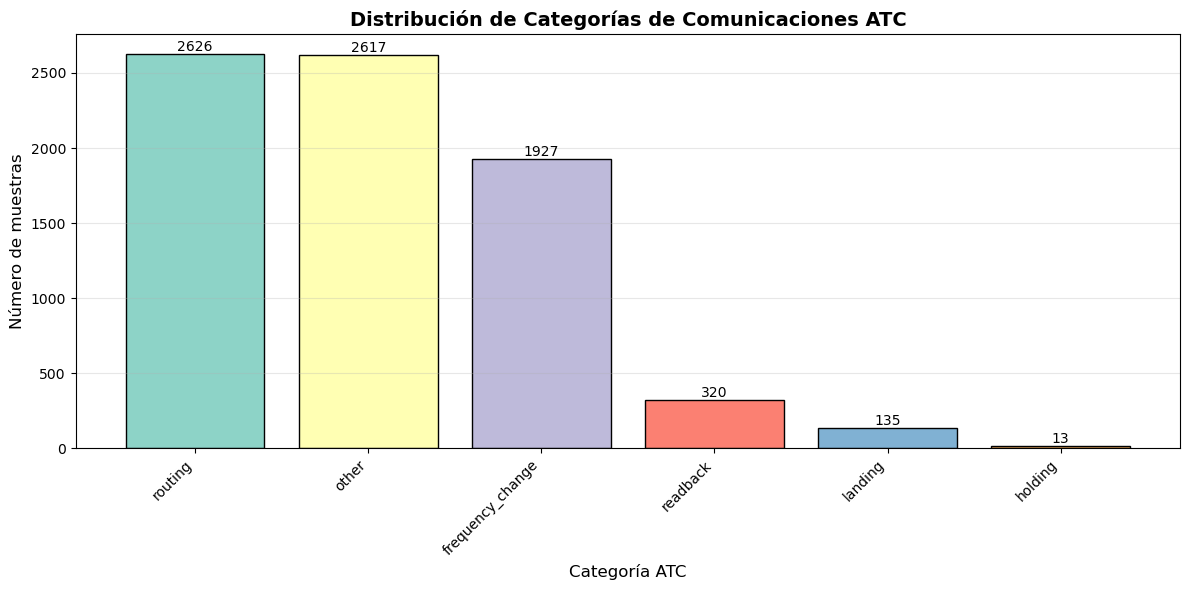


Ejemplos por categoría:


Categoría: ROUTING
1. psa eight one zero turn right to trasadingen
2. sabena four eight one turn left to dinkelsbuhl
3. swiss air nine three five two climb flight level three five zero set course to gotil

Categoría: FREQUENCY_CHANGE
1. lufthansa five three one eight contact zurich one three four decimal six
2. psa eight one zero contact zurich one three three decimal four
3. india oscar kilo contact rhein one two seven three seven

Categoría: OTHER
1. sabena four eight one rhein identified
2. transwede one zero one rhein identified set course trasadingen
3. trans avia three eight one zurich radar one three four decimal six

Categoría: READBACK
1. roger keep this rate until reaching
2. roger identified
3. affirm lufthansa four three nine zero contact zurich one three four decimal six

Categoría: LANDING
1. netherlands air force three four identified
2. midland seven two zero rhein radar identified
3. midland seven two zero turn right by one five degrees

Cate

In [59]:
def categorize_atc_message(text):
    """
    Categoriza mensajes ATC basándose en palabras clave
    """
    if not isinstance(text, str) or text == '':
        return 'unknown'
    
    text_lower = text.lower()
    
    if any(word in text_lower for word in ['takeoff', 'take off', 'cleared for takeoff', 'departure']):
        return 'takeoff'
    elif any(word in text_lower for word in ['landing', 'land', 'cleared to land', 'approach', 'final']):
        return 'landing'
    elif any(word in text_lower for word in ['climb', 'descend', 'altitude', 'flight level', 'heading', 'turn']):
        return 'routing'
    elif any(word in text_lower for word in ['roger', 'wilco', 'affirm', 'negative', 'correct', 'read back']):
        return 'readback'
    elif any(word in text_lower for word in ['hold', 'holding', 'wait', 'standby']):
        return 'holding'
    elif any(word in text_lower for word in ['contact', 'frequency', 'squawk']):
        return 'frequency_change'
    else:
        return 'other'

if text_columns:
    text_col = text_columns[0]
    df_train['atc_category'] = df_train[text_col].apply(categorize_atc_message)
    
    print("️Distribución de categorías ATC creadas:")
    print(df_train['atc_category'].value_counts())
    
    plt.figure(figsize=(12, 6))
    category_counts = df_train['atc_category'].value_counts()
    colors = plt.cm.Set3(range(len(category_counts)))
    
    bars = plt.bar(range(len(category_counts)), category_counts.values, color=colors, edgecolor='black')
    plt.xticks(range(len(category_counts)), category_counts.index, rotation=45, ha='right')
    plt.xlabel('Categoría ATC', fontsize=12)
    plt.ylabel('Número de muestras', fontsize=12)
    plt.title('Distribución de Categorías de Comunicaciones ATC', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\nEjemplos por categoría:\n")
    unique_categories = df_train['atc_category'].unique()
    for category in unique_categories[:7]:  # Máximo 7 categorías para no saturar
        print(f"\n{'='*80}")
        print(f"Categoría: {category.upper()}")
        print(f"{'='*80}")
        examples = df_train[df_train['atc_category'] == category][text_col].head(3)
        for i, ex in enumerate(examples, 1):
            print(f"{i}. {ex}")
else:
    print("\n️No hay columnas de texto para categorizar")

##  Conclusiones del EDA

**Resumen de hallazgos:**

In [60]:
print("="*80)
print("RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("="*80)

print(f"\n1 DATASET:")
print(f"   - Total de muestras: {len(df_train)}")
if len(df_audio_info) > 0:
    total_duration = df_audio_info['duration'].sum() / 3600
    estimated_total = (total_duration / len(df_audio_info)) * len(train_data)
    print(f"   - Duración analizada: {total_duration:.2f} horas")
    print(f"   - Duración total estimada: {estimated_total:.2f} horas")
    print(f"   - Sample rate predominante: {df_audio_info['sample_rate'].mode()[0]} Hz")

if len(df_audio_info) > 0:
    print(f"\n2 AUDIO:")
    print(f"   - Duración promedio: {df_audio_info['duration'].mean():.2f} segundos")
    print(f"   - Duración mínima: {df_audio_info['duration'].min():.2f} segundos")
    print(f"   - Duración máxima: {df_audio_info['duration'].max():.2f} segundos")

if text_columns and 'text_length' in df_train.columns:
    print(f"\n3 TRANSCRIPCIONES:")
    print(f"   - Longitud promedio: {df_train['text_length'].mean():.0f} caracteres")
    print(f"   - Palabras promedio: {df_train['word_count'].mean():.0f} palabras")

if 'atc_category' in df_train.columns:
    print(f"\n4 CATEGORÍAS:")
    for cat, count in df_train['atc_category'].value_counts().items():
        percentage = (count / len(df_train)) * 100
        print(f"   - {cat}: {count} ({percentage:.1f}%)")
    
    max_count = df_train['atc_category'].value_counts().max()
    min_count = df_train['atc_category'].value_counts().min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\n5 BALANCE DE CLASES:")
    if imbalance_ratio > 5:
        print(f"   ️ Dataset DESBALANCEADO (ratio: {imbalance_ratio:.1f}:1)")
        print(f"   → Considerar técnicas de balanceo (oversampling, undersampling, pesos de clase)")
    elif imbalance_ratio > 2:
        print(f"    Dataset MODERADAMENTE desbalanceado (ratio: {imbalance_ratio:.1f}:1)")
        print(f"   → Monitorear métricas por clase (precision, recall, F1)")
    else:
        print(f"    Dataset BALANCEADO (ratio: {imbalance_ratio:.1f}:1)")

print(f"\n6 PRÓXIMOS PASOS:")
print(f"   1. Preprocesamiento de audio (normalización, data augmentation)")
print(f"   2. Extracción de features completa (MFCCs, Mel-spectrograms)")
print(f"   3. Modelo baseline con ML clásico (SVM, Random Forest)")
print(f"   4. Modelos DL from scratch (CNN, RNN/LSTM)")
print(f"   5. Transfer learning (Wav2Vec 2.0, Whisper)")
print(f"   6. Comparación con APIs comerciales")

print("\n" + "="*80)


RESUMEN DEL ANÁLISIS EXPLORATORIO

1 DATASET:
   - Total de muestras: 7638
   - Duración analizada: 0.12 horas
   - Duración total estimada: 9.03 horas
   - Sample rate predominante: 16000 Hz

2 AUDIO:
   - Duración promedio: 4.26 segundos
   - Duración mínima: 1.43 segundos
   - Duración máxima: 20.60 segundos

3 TRANSCRIPCIONES:
   - Longitud promedio: 63 caracteres
   - Palabras promedio: 11 palabras

4 CATEGORÍAS:
   - routing: 2626 (34.4%)
   - other: 2617 (34.3%)
   - frequency_change: 1927 (25.2%)
   - readback: 320 (4.2%)
   - landing: 135 (1.8%)
   - holding: 13 (0.2%)

5 BALANCE DE CLASES:
   ️ Dataset DESBALANCEADO (ratio: 202.0:1)
   → Considerar técnicas de balanceo (oversampling, undersampling, pesos de clase)

6 PRÓXIMOS PASOS:
   1. Preprocesamiento de audio (normalización, data augmentation)
   2. Extracción de features completa (MFCCs, Mel-spectrograms)
   3. Modelo baseline con ML clásico (SVM, Random Forest)
   4. Modelos DL from scratch (CNN, RNN/LSTM)
   5. Transf

##  5. Guardar Dataset Procesado

Guardamos el dataset con las nuevas columnas creadas para uso futuro.

In [61]:
output_path = NOTEBOOK_OUTPUT_DIR / 'atcosim_processed.csv'

columns_to_save = [col for col in df_train.columns if col != 'audio']

try:
    df_train[columns_to_save].to_csv(output_path, index=False)
    print(f"Dataset procesado guardado en: {output_path}")
    print(f"Columnas guardadas: {columns_to_save}")
    print(f"Total de filas: {len(df_train)}")
except Exception as e:
    print(f"️ Error al guardar: {e}")

Dataset procesado guardado en: outputs/ADNE_Proyecto_Audio_ATC_EDA/atcosim_processed.csv
Columnas guardadas: ['id', 'text', 'segment_start_time', 'segment_end_time', 'duration', 'text_length', 'word_count', 'atc_category']
Total de filas: 7638
